In [20]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# 0. CREAR CARPETA OUTPUT
# =========================
output_dir = Path("")
output_dir.mkdir(exist_ok=True)

# =========================
# 1. RUTA DEL ARCHIVO IMP
# =========================
ruta_hogares = "ETAPA 6 - COMPARACIONES IMP/data 2018/Hogares/Hogares (departamental) .csv"


# =========================
# 2. FUNCIONES AUXILIARES
# =========================
def limpiar_decimal_coma(serie):
    s = serie.astype(str).str.strip()
    s = s.str.replace(".", "", regex=False)
    s = s.str.replace(",", ".", regex=False)
    s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan})
    return pd.to_numeric(s, errors="coerce")

def media_ponderada(x, w):
    mask = x.notna() & w.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(x[mask], weights=w[mask])

# =========================
# 3. LEER ARCHIVO IMP
# =========================
hog = pd.read_csv(ruta_hogares, sep=";", dtype=str, encoding="utf-8-sig")
hog.columns = [c.strip().replace("\ufeff", "") for c in hog.columns]

# =========================
# 4. CONVERTIR COLUMNAS NECESARIAS
# =========================
cols_numericas = [
    "DEPARTAMENTO",
    "personas",
    "paredes",
    "pisos",
    "alcantarillado",
    "acueducto",
    "empleo_formal",
    "desempleo_larga_duracion",
    "barreras_acceso_salud",
    "aseguramiento_salud",
    "trabajo_infantil",
    "atencion_integral",
    "inasistencia_escolar",
    "rezago_escolar",
    "alfabetismo",
    "logro_educativo",
    "hacinamiento",
    "ipm",
    "pobre",
    "fex_c",
    "fexp"
]

for col in cols_numericas:
    hog[col] = limpiar_decimal_coma(hog[col])

# =========================
# 5. FILTRAR LOS 3 DEPARTAMENTOS
# =========================
mapa_deptos = {
    63: "Quindío",
    66: "Risaralda",
    76: "Valle del Cauca"
}

hog_3 = hog[hog["DEPARTAMENTO"].isin(mapa_deptos.keys())].copy()
hog_3["NOMBRE_DEPTO"] = hog_3["DEPARTAMENTO"].map(mapa_deptos)

# Peso principal
hog_3["peso"] = hog_3["fexp"]
hog_3.loc[hog_3["peso"].isna(), "peso"] = hog_3.loc[hog_3["peso"].isna(), "fex_c"]

# =========================
# 6. VARIABLES A RESUMIR
# =========================
vars_depto = [
    "ipm",
    "pobre",
    "hacinamiento",
    "acueducto",
    "alcantarillado",
    "alfabetismo",
    "inasistencia_escolar",
    "rezago_escolar",
    "logro_educativo",
    "empleo_formal",
    "desempleo_larga_duracion",
    "paredes",
    "pisos"
]

# =========================
# 7. RESUMEN DEPARTAMENTAL
# =========================
filas = []

for (cod, nombre), g in hog_3.groupby(["DEPARTAMENTO", "NOMBRE_DEPTO"], dropna=False):
    fila = {
        "DEPARTAMENTO": int(cod),
        "NOMBRE_DEPTO": nombre,
        "N_HOGARES_MUESTRA": len(g),
        "PERSONAS_MUESTRA": g["personas"].sum()
    }

    for var in vars_depto:
        fila[var] = media_ponderada(g[var], g["peso"])

    filas.append(fila)

df_deptos = pd.DataFrame(filas)

df_deptos = df_deptos[
    ["DEPARTAMENTO", "NOMBRE_DEPTO", "N_HOGARES_MUESTRA", "PERSONAS_MUESTRA"] + vars_depto
].copy()

df_deptos[vars_depto] = df_deptos[vars_depto].round(4)

print("Resumen departamental IMP")
display(df_deptos)

ruta_salida_deptos = output_dir / "ETAPA 6 - COMPARACIONES IMP/output/resumen_departamental_imp.csv"
df_deptos.to_csv(ruta_salida_deptos, index=False, encoding="utf-8-sig")
print(f"Guardado: {ruta_salida_deptos}")

Resumen departamental IMP


,DEPARTAMENTO,NOMBRE_DEPTO,N_HOGARES_MUESTRA,PERSONAS_MUESTRA,ipm,pobre,hacinamiento,acueducto,alcantarillado,alfabetismo,inasistencia_escolar,rezago_escolar,logro_educativo,empleo_formal,desempleo_larga_duracion,paredes,pisos
0,63,Quindío,3236,9228,0.1993,0.1624,0.0519,0.0376,0.0246,0.1019,0.0340,0.3479,0.4787,0.7414,0.1024,0.0484,0.0023
1,66,Risaralda,3207,9358,0.1875,0.1246,0.0773,0.0672,0.0526,0.0880,0.0451,0.3722,0.4737,0.7241,0.0891,0.0084,0.0039
2,76,Valle del Cauca,3144,9422,0.1832,0.1355,0.0844,0.0451,0.0624,0.0691,0.0382,0.3339,0.4183,0.7140,0.0741,0.0262,0.0069


Guardado: ETAPA 6 - COMPARACIONES IMP\output\resumen_departamental_imp.csv


In [21]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# 0. CREAR CARPETA OUTPUT
# =========================
output_dir = Path("")
output_dir.mkdir(exist_ok=True)

# =========================
# 1. RUTAS DE LOS ARCHIVOS EXTRA
# =========================
ruta_armenia = "ETAPA 4 - CLUSTERING/outputs/armenia_clusters_final_extra.csv"
ruta_cali    = "ETAPA 4 - CLUSTERING/outputs/cali_clusters_final_extra.csv"
ruta_pereira = "ETAPA 4 - CLUSTERING/outputs/pereira_clusters_final_extra.csv"

# =========================
# 2. FUNCIÓN DE RESUMEN
# =========================
def resumir_ciudad_extra(ruta_csv, nombre_ciudad, nombre_depto):
    df = pd.read_csv(ruta_csv, encoding="utf-8-sig")
    df.columns = [c.strip().replace("\ufeff", "") for c in df.columns]

    agg_dict = {
        "CLUSTER": "first",
        "estrato_promedio": "first",
        "personas_por_cuarto": "first",
        "personas_por_dormitorio": "first",
        "pct_alfabeta": "first",
        "pct_asistencia": "first",
        "pct_trabaja": "first",
        "pct_enfermo": "first",
        "servicios_disponibles": "first",
        "servicios_faltantes": "first",
        "P_NIVEL_ANOSR": "first",
        "P_EDADR": "first",
        "HA_TOT_PER": "first",
        "H_NRO_CUARTOS": "first",
        "H_NRO_DORMIT": "first",
        "IND_SERVICIOS": "first",
        "IND_EDUCACION": "first",
        "IND_LABORAL": "first",
        "IND_POBREZA_HAB": "first",
        "IND_MULTIDIM": "first",
        "pct_con_acueducto": "first",
        "pct_con_alcantarillado": "first",
        "pct_con_gas": "first",
        "pct_con_recoleccion_basuras": "first",
        "pct_con_internet": "first"
    }

    agg_dict = {k: v for k, v in agg_dict.items() if k in df.columns}

    df_manz = df.groupby("COD_DANE_ANM", as_index=False).agg(agg_dict)

    resumen = {
        "CIUDAD": nombre_ciudad,
        "NOMBRE_DEPTO": nombre_depto,
        "N_MANZANAS": df_manz["COD_DANE_ANM"].nunique()
    }

    vars_ciudad = [
        "estrato_promedio",
        "personas_por_cuarto",
        "personas_por_dormitorio",
        "pct_alfabeta",
        "pct_asistencia",
        "pct_trabaja",
        "pct_enfermo",
        "servicios_disponibles",
        "servicios_faltantes",
        "P_NIVEL_ANOSR",
        "P_EDADR",
        "HA_TOT_PER",
        "H_NRO_CUARTOS",
        "H_NRO_DORMIT",
        "IND_SERVICIOS",
        "IND_EDUCACION",
        "IND_LABORAL",
        "IND_POBREZA_HAB",
        "IND_MULTIDIM",
        "pct_con_acueducto",
        "pct_con_alcantarillado",
        "pct_con_gas",
        "pct_con_recoleccion_basuras",
        "pct_con_internet"
    ]

    for var in vars_ciudad:
        if var in df_manz.columns:
            resumen[var] = df_manz[var].mean()

    return resumen

# =========================
# 3. GENERAR RESUMEN DE CIUDADES
# =========================
resumen_ciudades = [
    resumir_ciudad_extra(ruta_armenia, "Armenia", "Quindío"),
    resumir_ciudad_extra(ruta_cali, "Cali", "Valle del Cauca"),
    resumir_ciudad_extra(ruta_pereira, "Pereira", "Risaralda")
]

df_ciudades = pd.DataFrame(resumen_ciudades)

cols_num = [c for c in df_ciudades.columns if c not in ["CIUDAD", "NOMBRE_DEPTO"]]
df_ciudades[cols_num] = df_ciudades[cols_num].round(4)

print("Resumen de ciudades desde archivos extra")
display(df_ciudades)

ruta_salida_ciudades = output_dir / "ETAPA 6 - COMPARACIONES IMP/output/resumen_ciudades_extra.csv"
df_ciudades.to_csv(ruta_salida_ciudades, index=False, encoding="utf-8-sig")
print(f"Guardado: {ruta_salida_ciudades}")

Resumen de ciudades desde archivos extra


,CIUDAD,NOMBRE_DEPTO,N_MANZANAS,estrato_promedio,personas_por_cuarto,personas_por_dormitorio,pct_alfabeta,pct_asistencia,pct_trabaja,pct_enfermo,...,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB,IND_MULTIDIM,pct_con_acueducto,pct_con_alcantarillado,pct_con_gas,pct_con_recoleccion_basuras,pct_con_internet
0,Armenia,Quindío,3190,2.4032,1.0342,1.5427,95.1083,23.1353,39.8526,9.6372,...,0.1040,0.3507,0.0050,0.0239,0.1209,99.0550,97.8103,89.2942,99.0416,61.3717
1,Cali,Valle del Cauca,13617,2.4801,1.0892,1.6353,94.6021,23.5646,44.8667,12.8383,...,0.0978,0.3452,0.0067,0.0210,0.1177,98.4938,96.7377,85.7542,98.7842,69.7672
2,Pereira,Risaralda,3988,2.5037,1.0802,1.5819,94.8647,25.3264,43.1571,9.1724,...,0.1215,0.3596,0.0064,0.0298,0.1294,98.9396,95.2362,83.8210,98.5582,61.8634


Guardado: ETAPA 6 - COMPARACIONES IMP\output\resumen_ciudades_extra.csv


In [23]:
import pandas as pd
from pathlib import Path

# =========================
# 0. CARPETA OUTPUT
# =========================
output_dir = Path("")
output_dir.mkdir(exist_ok=True)

# =========================
# 1. CARGAR RESULTADOS PREVIOS
# =========================
ruta_deptos =  "ETAPA 6 - COMPARACIONES IMP/output/resumen_departamental_imp.csv"
ruta_ciudades =  "ETAPA 6 - COMPARACIONES IMP/output/resumen_ciudades_extra.csv"

df_deptos = pd.read_csv(ruta_deptos, encoding="utf-8-sig")
df_ciudades = pd.read_csv(ruta_ciudades, encoding="utf-8-sig")

# =========================
# 2. UNIR
# =========================
comparacion = df_ciudades.merge(
    df_deptos,
    on="NOMBRE_DEPTO",
    how="left",
    suffixes=("_CIUDAD", "_DEPTO")
)

# =========================
# 3. SELECCIONAR COLUMNAS CLAVE
# =========================
cols_comparacion = [
    "CIUDAD",
    "NOMBRE_DEPTO",
    "N_MANZANAS",
    "DEPARTAMENTO",

    # Ciudad
    "pct_con_acueducto",
    "pct_con_alcantarillado",
    "pct_alfabeta",
    "pct_asistencia",
    "pct_trabaja",
    "personas_por_cuarto",
    "IND_SERVICIOS",
    "IND_EDUCACION",
    "IND_LABORAL",
    "IND_POBREZA_HAB",
    "IND_MULTIDIM",

    # Departamento
    "acueducto",
    "alcantarillado",
    "alfabetismo",
    "inasistencia_escolar",
    "empleo_formal",
    "hacinamiento",
    "ipm",
    "pobre"
]

cols_comparacion = [c for c in cols_comparacion if c in comparacion.columns]

comparacion = comparacion[cols_comparacion].copy()
comparacion = comparacion.round(4)

print("Comparación ciudad vs departamento")
display(comparacion)

ruta_salida_comparacion = output_dir / "ETAPA 6 - COMPARACIONES IMP/output/comparacion_ciudad_vs_departamento.csv"
comparacion.to_csv(ruta_salida_comparacion, index=False, encoding="utf-8-sig")
print(f"Guardado: {ruta_salida_comparacion}")

Comparación ciudad vs departamento


,CIUDAD,NOMBRE_DEPTO,N_MANZANAS,DEPARTAMENTO,pct_con_acueducto,pct_con_alcantarillado,pct_alfabeta,pct_asistencia,pct_trabaja,personas_por_cuarto,...,IND_POBREZA_HAB,IND_MULTIDIM,acueducto,alcantarillado,alfabetismo,inasistencia_escolar,empleo_formal,hacinamiento,ipm,pobre
0,Armenia,Quindío,3190,63,99.0550,97.8103,95.1083,23.1353,39.8526,1.0342,...,0.0239,0.1209,0.0376,0.0246,0.1019,0.0340,0.7414,0.0519,0.1993,0.1624
1,Cali,Valle del Cauca,13617,76,98.4938,96.7377,94.6021,23.5646,44.8667,1.0892,...,0.0210,0.1177,0.0451,0.0624,0.0691,0.0382,0.7140,0.0844,0.1832,0.1355
2,Pereira,Risaralda,3988,66,98.9396,95.2362,94.8647,25.3264,43.1571,1.0802,...,0.0298,0.1294,0.0672,0.0526,0.0880,0.0451,0.7241,0.0773,0.1875,0.1246


Guardado: ETAPA 6 - COMPARACIONES IMP\output\comparacion_ciudad_vs_departamento.csv


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. CARGAR ARCHIVO
# =========================
df = pd.read_csv("ETAPA 6 - COMPARACIONES IMP/output/comparacion_ciudad_vs_departamento.csv", encoding="utf-8-sig")

# =========================
# 2. ASEGURAR TIPOS NUMÉRICOS
# =========================
cols_texto = ["CIUDAD", "NOMBRE_DEPTO"]

for col in df.columns:
    if col not in cols_texto:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# 3. PASAR VARIABLES DE CIUDAD DE 0-100 A 0-1
# =========================
cols_pct_ciudad = [
    "pct_con_acueducto",
    "pct_con_alcantarillado",
    "pct_alfabeta",
    "pct_asistencia",
    "pct_trabaja"
]

for col in cols_pct_ciudad:
    if col in df.columns:
        df[col] = df[col] / 100.0

# =========================
# 4. CONSTRUIR TABLA COMPARATIVA
# =========================
df_comp = df.copy()

# SERVICIOS
df_comp["SERV_CIUDAD"] = df_comp[[
    "pct_con_acueducto",
    "pct_con_alcantarillado"
]].mean(axis=1)

# En IMP estas variables normalmente representan carencia
df_comp["SERV_DEPTO"] = 1 - df_comp[[
    "acueducto",
    "alcantarillado"
]].mean(axis=1)

# EDUCACIÓN
df_comp["EDU_CIUDAD"] = df_comp[[
    "pct_alfabeta",
    "pct_asistencia"
]].mean(axis=1)

# OJO:
# alfabetismo e inasistencia_escolar en IMP no necesariamente tienen el mismo sentido.
# Aquí seguimos la lógica de aproximación que veníamos usando.
df_comp["EDU_DEPTO"] = 1 - df_comp[[
    "alfabetismo",
    "inasistencia_escolar"
]].mean(axis=1)

# LABORAL
df_comp["LAB_CIUDAD"] = df_comp["pct_trabaja"]
df_comp["LAB_DEPTO"] = df_comp["empleo_formal"]

# HABITACIONAL
# Aquí NO conviene restar directamente porque no están en la misma métrica exacta.
df_comp["HAB_CIUDAD"] = df_comp["personas_por_cuarto"]
df_comp["HAB_DEPTO"] = df_comp["hacinamiento"]

# MULTIDIMENSIONAL
df_comp["MULTI_CIUDAD"] = df_comp["IND_MULTIDIM"]
df_comp["MULTI_DEPTO"] = df_comp["ipm"]

# =========================
# 5. DIFERENCIAS
# =========================
df_comp["DIF_SERV"] = df_comp["SERV_CIUDAD"] - df_comp["SERV_DEPTO"]
df_comp["DIF_EDU"] = df_comp["EDU_CIUDAD"] - df_comp["EDU_DEPTO"]
df_comp["DIF_LAB"] = df_comp["LAB_CIUDAD"] - df_comp["LAB_DEPTO"]
df_comp["DIF_MULTI"] = df_comp["MULTI_CIUDAD"] - df_comp["MULTI_DEPTO"]

# =========================
# 6. TABLA FINAL
# =========================
cols_final = [
    "CIUDAD",
    "NOMBRE_DEPTO",
    "SERV_CIUDAD", "SERV_DEPTO", "DIF_SERV",
    "EDU_CIUDAD", "EDU_DEPTO", "DIF_EDU",
    "LAB_CIUDAD", "LAB_DEPTO", "DIF_LAB",
    "HAB_CIUDAD", "HAB_DEPTO",
    "MULTI_CIUDAD", "MULTI_DEPTO", "DIF_MULTI"
]

tabla_final = df_comp[cols_final].round(4)

display(
    tabla_final.style.format({
        col: "{:.4f}" for col in tabla_final.columns if col not in ["CIUDAD", "NOMBRE_DEPTO"]
    })
)

,CIUDAD,NOMBRE_DEPTO,SERV_CIUDAD,SERV_DEPTO,DIF_SERV,EDU_CIUDAD,EDU_DEPTO,DIF_EDU,LAB_CIUDAD,LAB_DEPTO,DIF_LAB,HAB_CIUDAD,HAB_DEPTO,MULTI_CIUDAD,MULTI_DEPTO,DIF_MULTI
0,Armenia,Quindío,0.9843,0.9689,0.0154,0.5912,0.9320,-0.3408,0.3985,0.7414,-0.3429,1.0342,0.0519,0.1209,0.1993,-0.0784
1,Cali,Valle del Cauca,0.9762,0.9462,0.0299,0.5908,0.9464,-0.3555,0.4487,0.7140,-0.2653,1.0892,0.0844,0.1177,0.1832,-0.0655
2,Pereira,Risaralda,0.9709,0.9401,0.0308,0.6010,0.9334,-0.3325,0.4316,0.7241,-0.2925,1.0802,0.0773,0.1294,0.1875,-0.0581


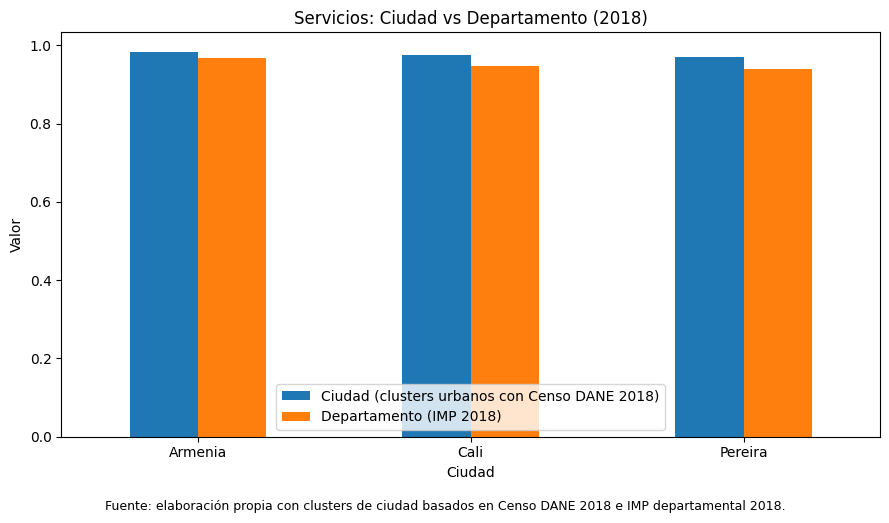

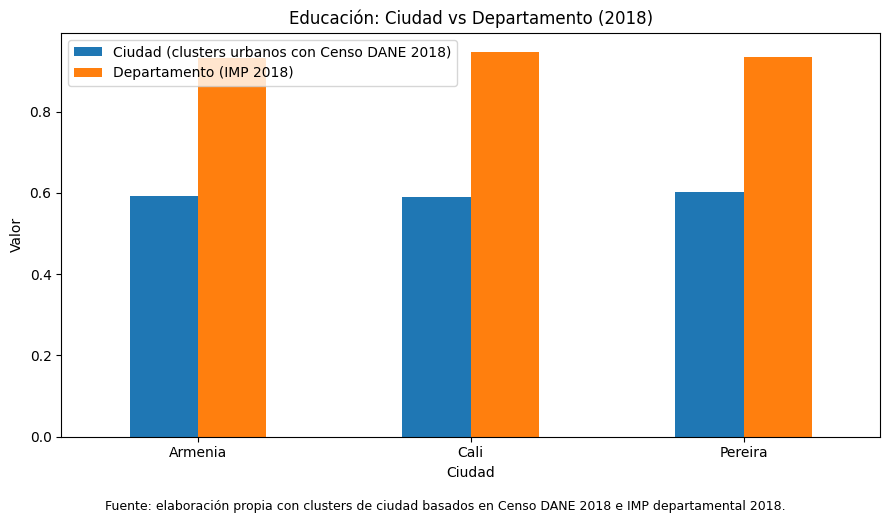

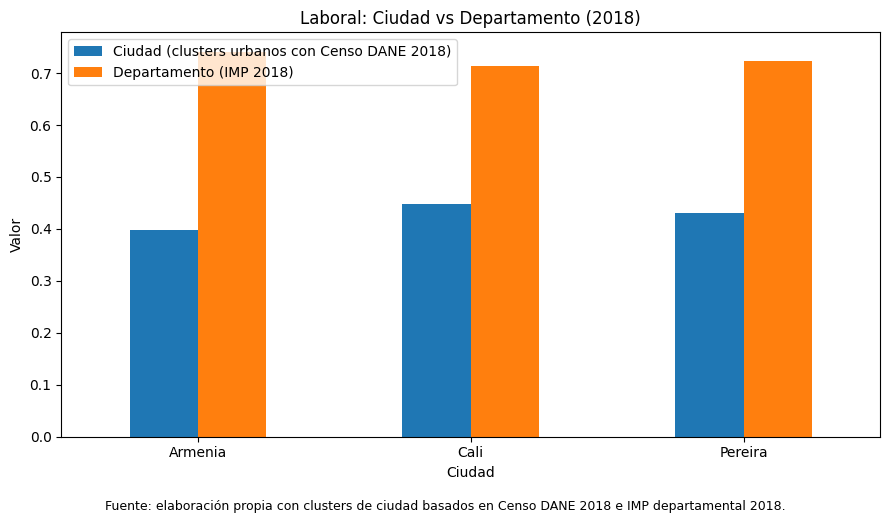

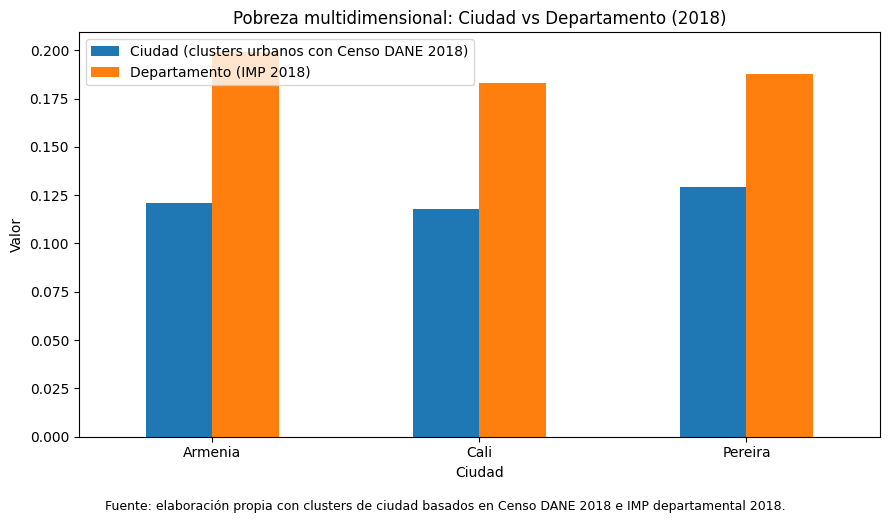

In [29]:
import matplotlib.pyplot as plt

df_plot = tabla_final.set_index("CIUDAD")

graficos = [
    ("SERV_CIUDAD", "SERV_DEPTO", "Servicios"),
    ("EDU_CIUDAD", "EDU_DEPTO", "Educación"),
    ("LAB_CIUDAD", "LAB_DEPTO", "Laboral"),
    ("MULTI_CIUDAD", "MULTI_DEPTO", "Pobreza multidimensional")
]

for col_ciudad, col_depto, dimension in graficos:
    ax = df_plot[[col_ciudad, col_depto]].plot(kind="bar", figsize=(9,5))
    
    ax.set_title(f"{dimension}: Ciudad vs Departamento (2018)")
    ax.set_ylabel("Valor")
    ax.set_xlabel("Ciudad")
    ax.set_xticklabels(df_plot.index, rotation=0)

    # Cambiar nombres de leyenda
    ax.legend([
        "Ciudad (clusters urbanos con Censo DANE 2018)",
        "Departamento (IMP 2018)"
    ])

    # Nota al pie dentro del gráfico
    plt.figtext(
        0.5, -0.03,
        "Fuente: elaboración propia con clusters de ciudad basados en Censo DANE 2018 e IMP departamental 2018.",
        ha="center", fontsize=9
    )

    plt.tight_layout()
    plt.show()